# Análisis de `resultados.csv`

Este cuaderno analiza el comportamiento de los métodos `sa`, `sqa`, `qaoa` y `qaoa_warmstart` sobre el problema de *knapsack*.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.font_manager as fm

from scipy import stats
from matplotlib.ticker import MaxNLocator

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

font_dir = Path("/Users/anabulchand/Downloads/cmu-serif")

for font_file in font_dir.glob("*.ttf"):
    fm.fontManager.addfont(str(font_file))

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False
})

Path("figuras").mkdir(exist_ok=True)


In [2]:
df = pd.read_csv('resultados.csv', na_values=['N/A'])

print('Dimensiones:', df.shape)
display(df.head())

Dimensiones: (320, 25)


,id,num_items,capacidad,num_variables_qubo,optimo,metodo,valor_total,peso,factible,ratio_optimo,tiempo_total,prob_optimo_starts,prob_optimo_muestras,tasa_factibilidad,ratio_medio_factibles,starts,total_muestras,tiempo_por_eval,total_evals,warmstart,epsilon_warmstart,sqa_beta,sqa_gamma,sqa_trotter,sqa_num_sweeps
0,201,2,5,5,9,qaoa_warmstart,9,5,True,1.0000,436.2139,0.8000,NaN,1.0000,0.9111,10,NaN,0.1738,"2,510.0000",True,0.2500,NaN,NaN,NaN,NaN
1,202,2,6,5,11,qaoa_warmstart,11,6,True,1.0000,386.3198,1.0000,NaN,1.0000,1.0000,10,NaN,0.1539,"2,510.0000",True,0.2500,NaN,NaN,NaN,NaN
2,203,2,5,5,8,qaoa_warmstart,8,5,True,1.0000,413.0037,0.7000,NaN,1.0000,0.8125,10,NaN,0.1645,"2,510.0000",True,0.2500,NaN,NaN,NaN,NaN
3,204,2,4,5,6,qaoa_warmstart,6,4,True,1.0000,471.0047,1.0000,NaN,1.0000,1.0000,10,NaN,0.1877,"2,510.0000",True,0.2500,NaN,NaN,NaN,NaN
4,301,3,5,6,9,qaoa_warmstart,9,5,True,1.0000,906.0691,0.8000,NaN,1.0000,0.9778,10,NaN,0.3610,"2,510.0000",True,0.2500,NaN,NaN,NaN,NaN


In [3]:
tabla_ejecuciones = (
    df.groupby(["id", "metodo"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=["qaoa", "qaoa_warmstart", "sa", "sqa"], fill_value=0)
)

tabla_ejecuciones["total"] = tabla_ejecuciones.sum(axis=1)

total = pd.DataFrame(
    [tabla_ejecuciones.sum()],
    index=["TOTAL"]
)

tabla_ejecuciones = pd.concat([tabla_ejecuciones, total])

display(tabla_ejecuciones)

metodo,qaoa,qaoa_warmstart,sa,sqa,total
201,5,5,5,5,20
202,5,5,5,5,20
203,5,5,5,5,20
204,5,5,5,5,20
301,5,5,5,5,20
302,5,5,5,5,20
303,5,5,5,5,20
304,5,5,5,5,20
401,5,5,5,5,20
402,5,5,5,5,20


In [4]:
variables_resumen = [
    "ratio_optimo",
    "tiempo_total",
    "prob_optimo_starts",
    "prob_optimo_muestras",
    "tasa_factibilidad",
    "ratio_medio_factibles",
    "starts",
    "total_muestras",
    "tiempo_por_eval",
    "total_evals",
    "sqa_beta",
    "sqa_gamma",
    "sqa_trotter",
    "sqa_num_sweeps"
]

for col in variables_resumen:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

variables_resumen = [c for c in variables_resumen if c in df.columns]

tabla_descriptivos = (
    df
    .groupby("metodo")[variables_resumen]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

import os

# Crear carpeta si no existe
os.makedirs("tablas", exist_ok=True)

# Guardar como CSV
tabla_descriptivos.to_csv("tablas/tabla_descriptivos.csv")

# Guardar como Excel
tabla_descriptivos.to_excel("tablas/tabla_descriptivos.xlsx")

# Guardar como LaTeX para Overleaf
with open("tablas/tabla_descriptivos.tex", "w", encoding="utf-8") as f:
    f.write(
        tabla_descriptivos.to_latex(
            float_format="%.4f",
            caption="Estadísticos descriptivos por método",
            label="tab:descriptivos_por_metodo",
            escape=False
        )
    )

display(tabla_descriptivos)

ratio_optimo                                    tiempo_total  \
                      count   mean median    std    min    max        count   
metodo                                                                        
qaoa                     80 1.0000 1.0000 0.0000 1.0000 1.0000           80   
qaoa_warmstart           80 0.9988 1.0000 0.0106 0.9048 1.0000           80   
sa                       80 1.0000 1.0000 0.0000 1.0000 1.0000           80   
sqa                      80 1.0000 1.0000 0.0000 1.0000 1.0000           80   

                                                                      \
                     mean     median        std      min         max   
metodo                                                                 
qaoa           6,118.9448 1,660.0145 7,191.6429 427.3249 18,865.4962   
qaoa_warmstart 3,736.2261 1,438.5927 3,786.2559 377.1099 10,449.6316   
sa                 0.0213     0.0207     0.0040   0.0156      0.0308   
sqa                0.3028     0.3000     0.0232   0.2647      0.3602   

               prob_optimo_starts                                     \
                            count   mean median    std    min    max   
metodo                                                                 
qaoa                           80 0.6975 0.7500 0.2408 0.2000 1.0000   
qaoa_warmstart                 80 0.6625 0.7000 0.2636 0.0000 1.0000   
sa                             80 0.8025 0.9000 0.2199 0.3000 1.0000   
sqa                            80 0.5000 0.4500 0.2333 0.2000 1.0000   

               prob_optimo_muestras                                     \
                              count   mean median    std    min    max   
metodo                                                                   
qaoa                              0    NaN    NaN    NaN    NaN    NaN   
qaoa_warmstart                    0    NaN    NaN    NaN    NaN    NaN   
sa                               80 0.2257 0.2250 0.1490 0.0300 0.5600   
sqa                              80 0.5000 0.4500 0.2333 0.2000 1.0000   

               tasa_factibilidad                                     \
                           count   mean median    std    min    max   
metodo                                                                
qaoa                          80 1.0000 1.0000 0.0000 1.0000 1.0000   
qaoa_warmstart                80 1.0000 1.0000 0.0000 1.0000 1.0000   
sa                            80 0.9899 1.0000 0.0135 0.9400 1.0000   
sqa                           80 1.0000 1.0000 0.0000 1.0000 1.0000   

               ratio_medio_factibles                                     \
                               count   mean median    std    min    max   
metodo                                                                    
qaoa                              80 0.9444 0.9463 0.0441 0.8000 1.0000   
qaoa_warmstart                    80 0.9416 0.9437 0.0474 0.7667 1.0000   
sa                                80 0.6228 0.6195 0.0683 0.4363 0.7557   
sqa                               80 0.8432 0.8418 0.1019 0.6125 1.0000   

               starts                                total_muestras           \
                count    mean  median    std min max          count     mean   
metodo                                                                         
qaoa               80 10.0000 10.0000 0.0000  10  10              0      NaN   
qaoa_warmstart     80 10.0000 10.0000 0.0000  10  10              0      NaN   
sa                 80 10.0000 10.0000 0.0000  10  10             80 100.0000   
sqa                80 10.0000 10.0000 0.0000  10  10             80 100.0000   

                                                 tiempo_por_eval         \
                 median    std      min      max           count   mean   
metodo                                                                    
qaoa                NaN    NaN      NaN      NaN              80 2.4378   
qaoa_warmstart      NaN    NaN      NaN      Na

### Análisis tiempo total de ejecución
#### Análisis tiempo de ejecución por método

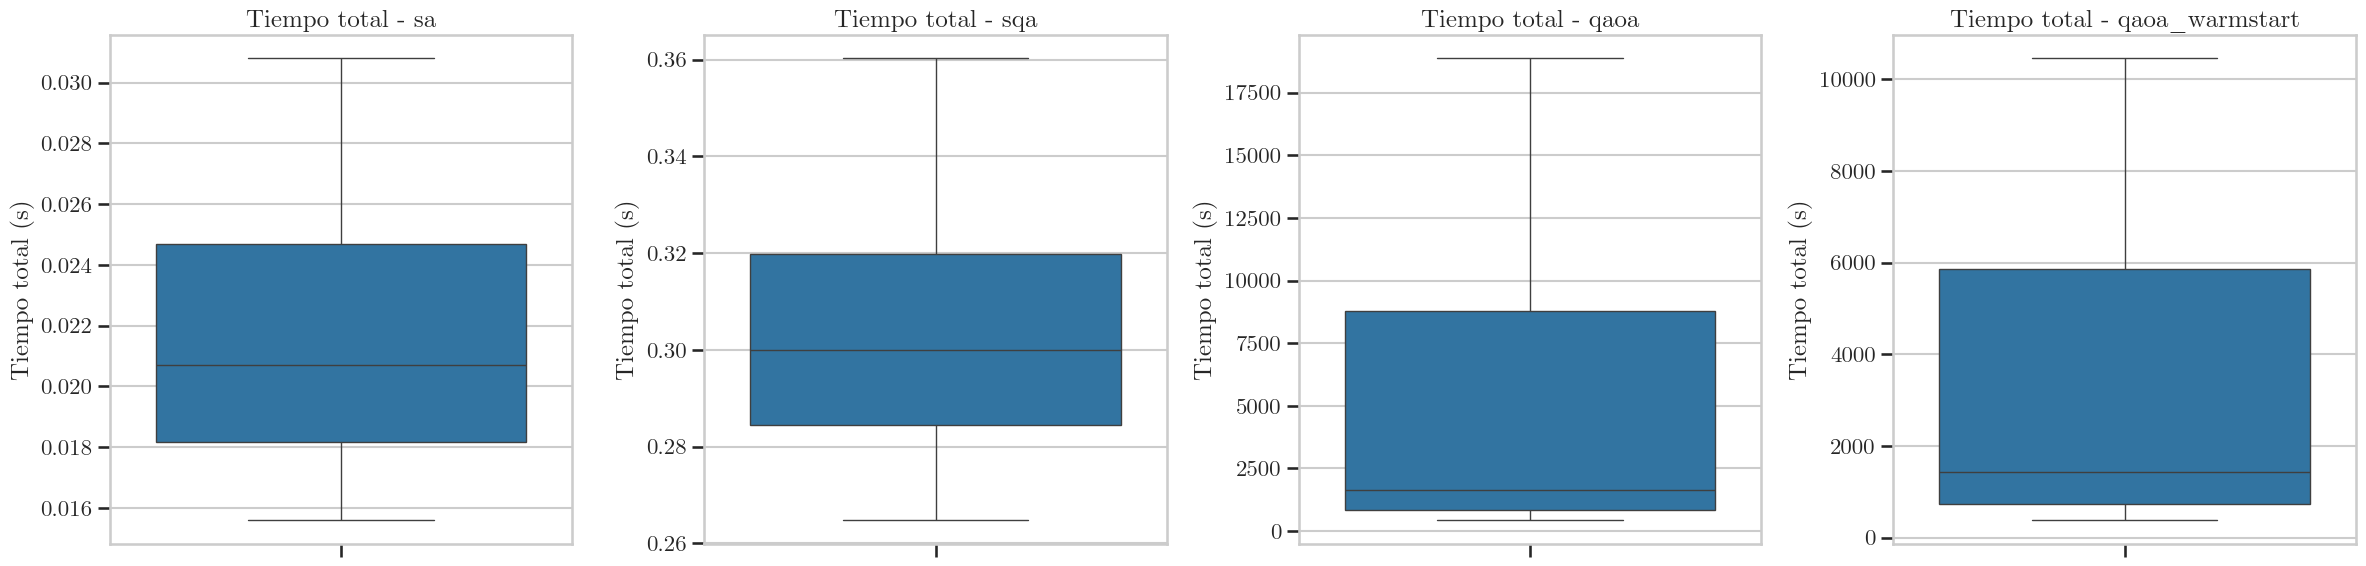

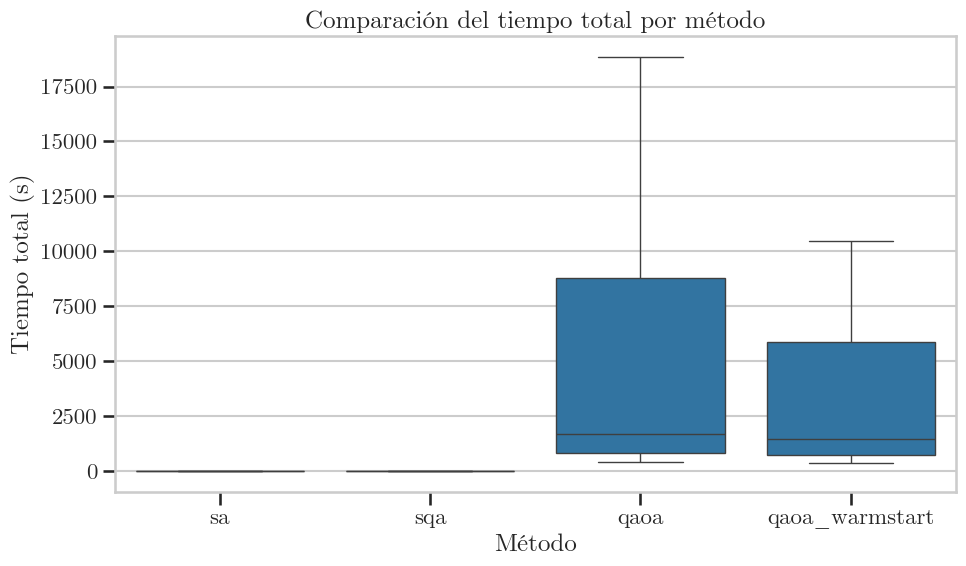

In [5]:
#Representación box-plot de cada método

metodos = ["sa", "sqa", "qaoa", "qaoa_warmstart"]
metodos = [m for m in metodos if m in df["metodo"].unique()]

#Gráficas individuales
fig, axes = plt.subplots(1, len(metodos), figsize=(6 * len(metodos), 6))

if len(metodos) == 1:
    axes = [axes]

for i, metodo in enumerate(metodos):
    sns.boxplot(
        data=df[df["metodo"] == metodo],
        y="tiempo_total",
        ax=axes[i],
        showfliers=True
    )
    axes[i].set_title(f"Tiempo total - {metodo}")
    axes[i].set_ylabel("Tiempo total (s)")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.savefig("figuras/boxplot_tiempo_total_por_metodo_individual_kp.png", dpi=300, bbox_inches="tight")
plt.show()

#Gráfica agregada
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="metodo",
    y="tiempo_total",
    order=metodos,
    showfliers=True
)

plt.title("Comparación del tiempo total por método")
plt.xlabel("Método")
plt.ylabel("Tiempo total (s)")

plt.tight_layout()
plt.savefig("figuras/boxplot_tiempo_total_comparacion_metodos_kp.png", dpi=300, bbox_inches="tight")
plt.show()


#### Análisis de escalabilidad con el tamaño del problema

metodo,sa,sqa,qaoa,qaoa_warmstart
num_items,,,,
2,0.0166,0.2848,483.1464,428.6164
3,0.0192,0.2871,992.4344,882.3038
4,0.0227,0.3091,"4,951.3059","3,882.8256"
5,0.0269,0.3300,"18,048.8925","9,751.1587"


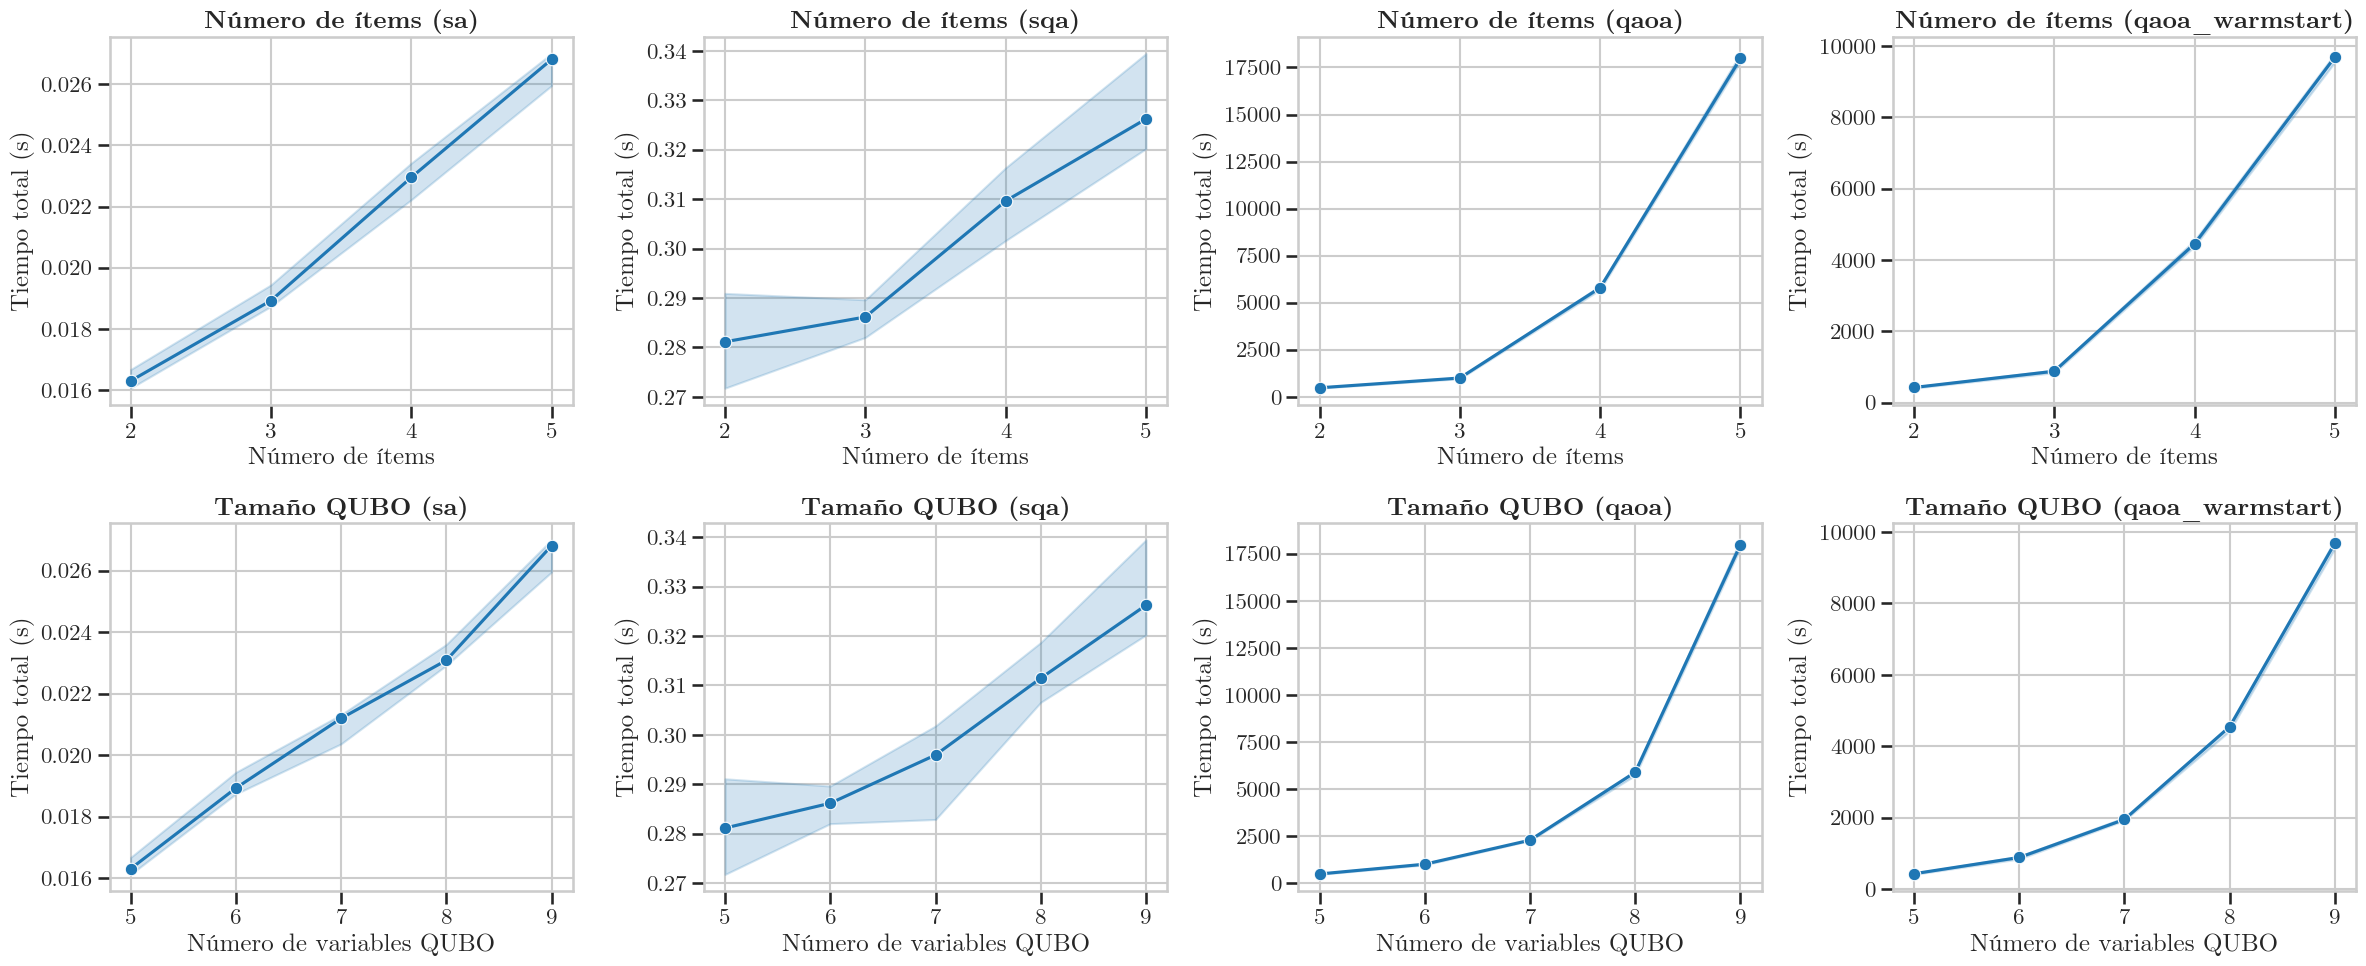

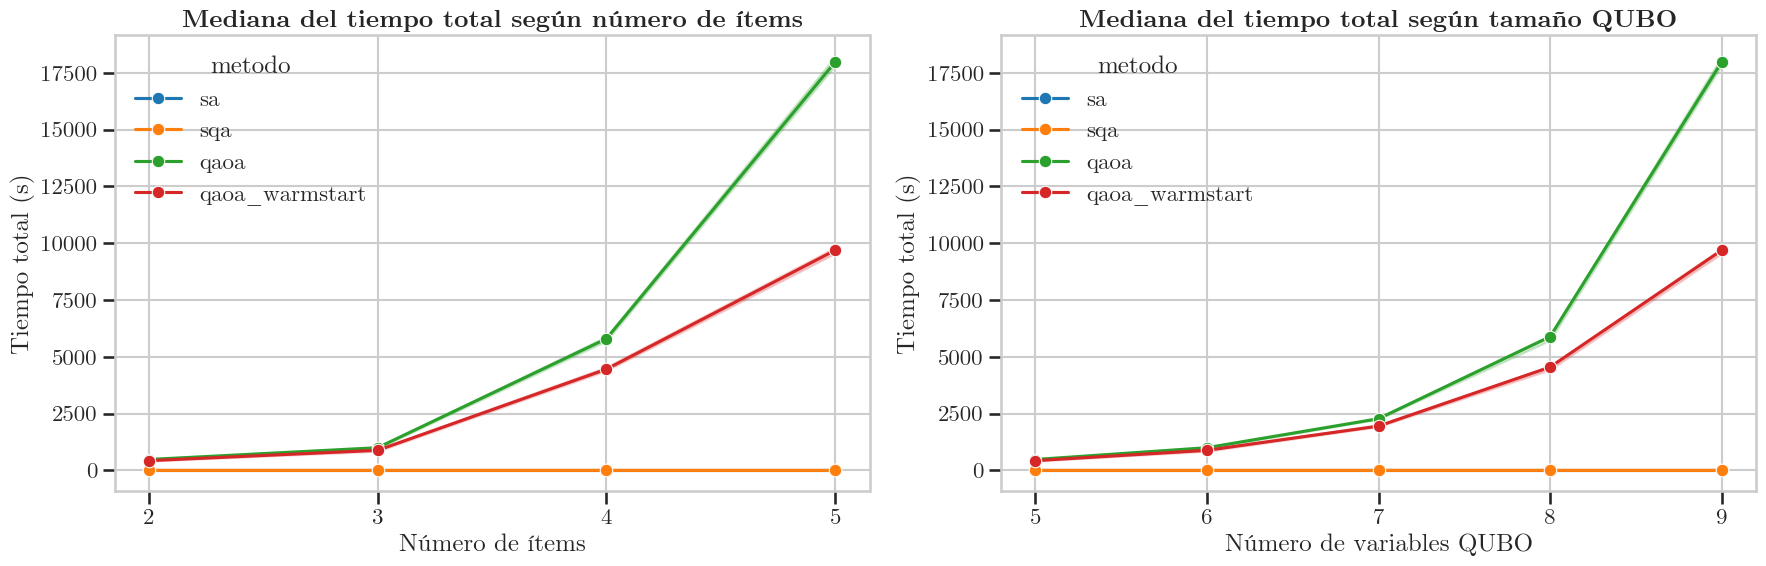

In [6]:
from matplotlib.ticker import MaxNLocator

columnas_numericas = [
    "id",
    "num_items",
    "capacidad",
    "num_variables_qubo",
    "optimo",
    "valor_total",
    "peso",
    "ratio_optimo",
    "tiempo_total"
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

metodos = ["sa", "sqa", "qaoa", "qaoa_warmstart"]
metodos = [m for m in metodos if m in df["metodo"].unique()]

#Tabla tiempo medio en base al número de items

tabla = (
    df
    .groupby(["num_items", "metodo"])["tiempo_total"]
    .mean()
    .unstack("metodo")
    .reindex(columns=metodos)
    .round(6)
)

display(tabla)

#Gráficos para cada método

fig, axes = plt.subplots(2, len(metodos), figsize=(6 * len(metodos), 10), sharey=False)

if len(metodos) == 1:
    axes = np.array(axes).reshape(2, 1)

# Escalabilidad con número de items
for i, metodo in enumerate(metodos):
    df_metodo = df[df["metodo"] == metodo].copy()

    sns.lineplot(
        data=df_metodo,
        x="num_items",
        y="tiempo_total",
        estimator="median",
        marker="o",
        ax=axes[0, i]
    )

    axes[0, i].set_title(f"Número de ítems ({metodo})", fontweight="bold")
    axes[0, i].set_xlabel("Número de ítems")
    axes[0, i].set_ylabel("Tiempo total (s)")
    axes[0, i].xaxis.set_major_locator(MaxNLocator(integer=True))

#Escalabilidad con tamaño del QUBO
for i, metodo in enumerate(metodos):
    df_metodo = df[df["metodo"] == metodo].copy()

    sns.lineplot(
        data=df_metodo,
        x="num_variables_qubo",
        y="tiempo_total",
        estimator="median",
        marker="o",
        ax=axes[1, i]
    )

    axes[1, i].set_title(f"Tamaño QUBO ({metodo})", fontweight="bold")
    axes[1, i].set_xlabel("Número de variables QUBO")
    axes[1, i].set_ylabel("Tiempo total (s)")
    axes[1, i].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("figuras/escalabilidad_tiempo_por_metodo.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# GRÁFICOS AGREGADOS
# =========================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=df,
    x="num_items",
    y="tiempo_total",
    hue="metodo",
    hue_order=metodos,
    estimator="median",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Mediana del tiempo total según número de ítems", fontweight="bold")
axes[0].set_xlabel("Número de ítems")
axes[0].set_ylabel("Tiempo total (s)")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

sns.lineplot(
    data=df,
    x="num_variables_qubo",
    y="tiempo_total",
    hue="metodo",
    hue_order=metodos,
    estimator="median",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Mediana del tiempo total según tamaño QUBO", fontweight="bold")
axes[1].set_xlabel("Número de variables QUBO")
axes[1].set_ylabel("Tiempo total (s)")
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("figuras/escalabilidad_tiempo_agregado.png", dpi=300, bbox_inches="tight")
plt.show()


## Contraste estadístico

In [10]:
import numpy as np
import pandas as pd
from scipy import stats

columnas_base = [
    "id",
    "num_items",
    "capacidad",
    "num_variables_qubo",
    "optimo"
]

df["instancia_clave"] = df[columnas_base].astype(str).agg(" | ".join, axis=1)

columnas_numericas = [
    "tiempo_total",
    "prob_optimo_starts",
    "prob_optimo_muestras",
    "ratio_medio_factibles",
    "tasa_factibilidad",
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")


def cohens_d_paired(x, y):
    diff = np.array(x) - np.array(y)
    std = diff.std(ddof=1)
    return diff.mean() / std if std != 0 else np.nan


def prueba_pareada(tabla, metodo_a, metodo_b, variable):
    x = tabla[metodo_a].dropna()
    y = tabla[metodo_b].dropna()

    datos = pd.concat([x, y], axis=1).dropna()
    x = datos[metodo_a]
    y = datos[metodo_b]
    diff = x - y

    shapiro_p = stats.shapiro(diff).pvalue if len(diff) >= 3 else np.nan

    if pd.notna(shapiro_p) and shapiro_p > 0.05:
        test_name = "t-test apareado"
        pvalue = stats.ttest_rel(x, y).pvalue
    else:
        test_name = "Wilcoxon"
        try:
            pvalue = stats.wilcoxon(x, y).pvalue
        except ValueError:
            pvalue = np.nan

    return {
        "variable": variable,
        "metodo_a": metodo_a,
        "metodo_b": metodo_b,
        "comparacion": f"{metodo_a} vs {metodo_b}",
        "n_pares": len(datos),
        "mediana_metodo_a": np.median(x),
        "mediana_metodo_b": np.median(y),
        "media_metodo_a": np.mean(x),
        "media_metodo_b": np.mean(y),
        "shapiro_p_diferencias": shapiro_p,
        "prueba": test_name,
        "p_valor": pvalue,
        "cohens_d_paired": cohens_d_paired(x, y)
    }


comparables = df[df["metodo"].isin(["qaoa", "qaoa_warmstart", "sqa"])].copy()

agg = comparables.groupby(["instancia_clave", "metodo"], as_index=False).agg({
    "tiempo_total": "median",
    "prob_optimo_starts": "median",
    "prob_optimo_muestras": "median",
    "ratio_medio_factibles": "median",
    "tasa_factibilidad": "median",
})

resultados = []

comparaciones = [
    ("qaoa", "qaoa_warmstart"),
    ("qaoa", "sqa"),
    ("qaoa_warmstart", "sqa")
]

#Comparación tiempo total

pivot_t = agg.pivot(
    index="instancia_clave",
    columns="metodo",
    values="tiempo_total"
)

for metodo_a, metodo_b in comparaciones:
    tabla = pivot_t[[metodo_a, metodo_b]].dropna()

    if len(tabla) >= 2:
        resultados.append(
            prueba_pareada(
                tabla=tabla,
                metodo_a=metodo_a,
                metodo_b=metodo_b,
                variable="tiempo_total"
            )
        )

#Comparación probabilidad óptimo por starts

pivot_p = agg.pivot(
    index="instancia_clave",
    columns="metodo",
    values="prob_optimo_starts"
)

for metodo_a, metodo_b in comparaciones:
    tabla = pivot_p[[metodo_a, metodo_b]].dropna()

    if len(tabla) >= 2:
        resultados.append(
            prueba_pareada(
                tabla=tabla,
                metodo_a=metodo_a,
                metodo_b=metodo_b,
                variable="prob_optimo_starts"
            )
        )

tabla_resultados = pd.DataFrame(resultados)

display(tabla_resultados)

,variable,metodo_a,metodo_b,comparacion,n_pares,mediana_metodo_a,mediana_metodo_b,media_metodo_a,media_metodo_b,shapiro_p_diferencias,prueba,p_valor,cohens_d_paired
0,tiempo_total,qaoa,qaoa_warmstart,qaoa vs qaoa_warmstart,16,"1,657.5880","1,447.7439","6,109.3479","3,713.0060",0.0000,Wilcoxon,0.0000,0.6684
1,tiempo_total,qaoa,sqa,qaoa vs sqa,16,"1,657.5880",0.2939,"6,109.3479",0.2993,0.0002,Wilcoxon,0.0000,0.8294
2,tiempo_total,qaoa_warmstart,sqa,qaoa_warmstart vs sqa,16,"1,447.7439",0.2939,"3,713.0060",0.2993,0.0009,Wilcoxon,0.0000,0.9653
3,prob_optimo_starts,qaoa,qaoa_warmstart,qaoa vs qaoa_warmstart,16,0.7500,0.7500,0.6875,0.6687,0.0058,Wilcoxon,0.3805,0.2059
4,prob_optimo_starts,qaoa,sqa,qaoa vs sqa,16,0.7500,0.4500,0.6875,0.5000,0.0760,t-test apareado,0.0030,0.8823
5,prob_optimo_starts,qaoa_warmstart,sqa,qaoa_warmstart vs sqa,16,0.7500,0.4500,0.6687,0.5000,0.3444,t-test apareado,0.0021,0.9295


## Correlaciones entre complejidad y coste computacional

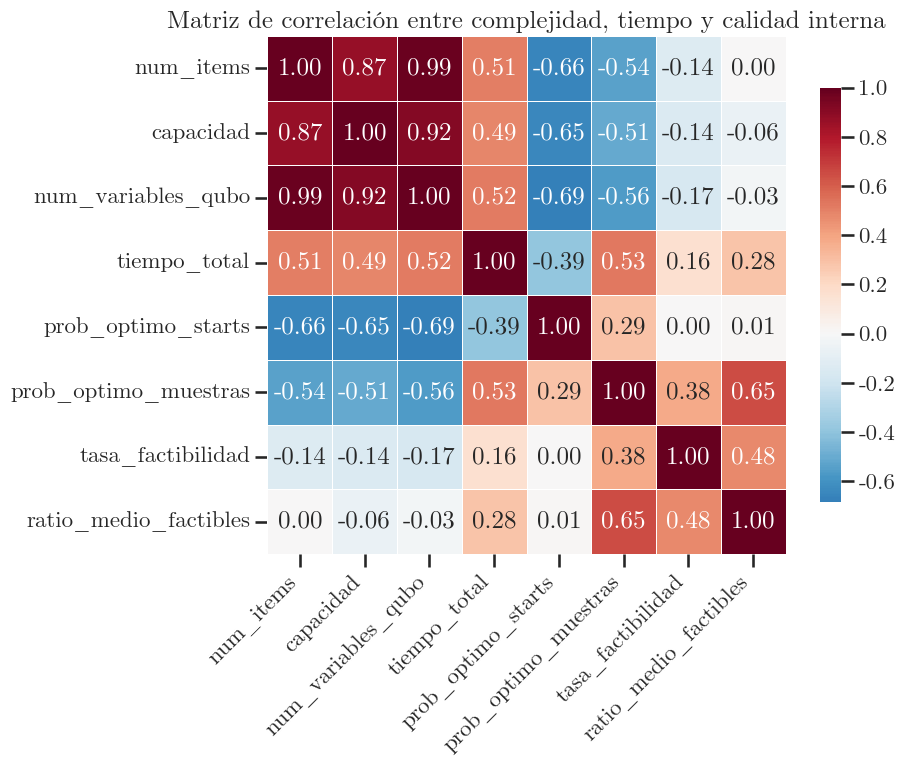

In [12]:
#Correlaciones entre complejidad y coste computacional
from pathlib import Path

cols_corr = [
    "num_items",
    "capacidad",
    "num_variables_qubo",
    "tiempo_total",
    "prob_optimo_starts",
    "prob_optimo_muestras",
    "tasa_factibilidad",
    "ratio_medio_factibles"
]

cols_corr = [c for c in cols_corr if c in df.columns]

for col in cols_corr:
    df[col] = pd.to_numeric(df[col], errors="coerce")

corr = df[cols_corr].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de correlación entre complejidad, tiempo y calidad interna")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

Path("figuras").mkdir(exist_ok=True)
plt.savefig("figuras/matriz_correlacion_complejidad_tiempo_calidad_kp.png", dpi=300, bbox_inches="tight")
plt.show()


## Cálculo tiempo total de ejecución

In [19]:
df["tiempo_total"] = pd.to_numeric(df["tiempo_total"], errors="coerce")

tiempos_por_metodo = (
    df.groupby("metodo", as_index=False)
    .agg(
        num_ejecuciones=("tiempo_total", "count"),
        tiempo_total_segundos=("tiempo_total", "sum"),
    )
    .sort_values("tiempo_total_segundos", ascending=False)
)

tiempo_total_global = df["tiempo_total"].sum()

display(tiempos_por_metodo)

print(f"Tiempo total global: {tiempo_total_global:.4f} segundos")

,metodo,num_ejecuciones,tiempo_total_segundos
0,qaoa,80,"489,515.5844"
1,qaoa_warmstart,80,"298,898.0885"
3,sqa,80,24.2214
2,sa,80,1.7061


Tiempo total global: 788439.6004 segundos
